In [5]:
import pandas as pd

In [12]:
df = pd.read_csv(r"C:\Users\Aishwarya\Downloads\telco.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
#DATA PREPROCESSING STARTS
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [15]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [17]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [19]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0:'No', 1:'Yes'})
df['Churn_Binary'] = df['Churn'].map({'Yes':1, 'No':0})
df.drop('customerID', axis=1, inplace=True)
df.drop_duplicates(inplace=True)
df.to_csv("clean.csv", index=False)
#DATA PREPROCESSING ENDS

In [20]:
#EDA STARTS
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10,6)
sns.set_style("whitegrid")

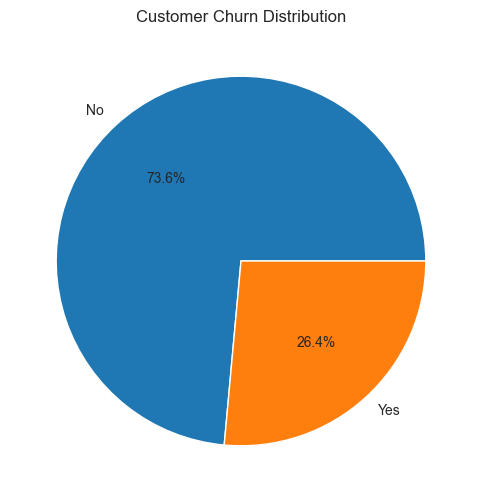

In [21]:
#GRAPH 1: Churn Distribution
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.show()

In [22]:
#Around 26–27% customers churned → serious issue

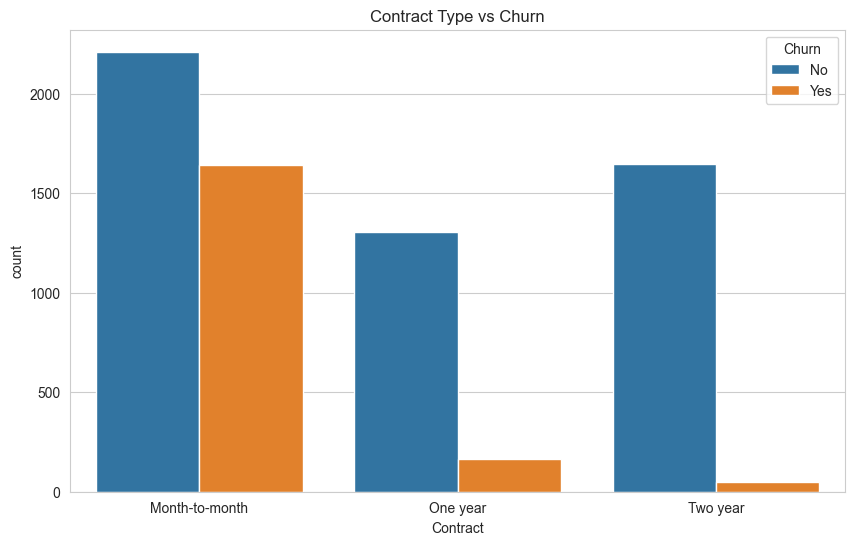

In [23]:
#GRAPH 2: Contract vs Churn
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Contract Type vs Churn")
plt.show()

In [24]:
#Month-to-month customers churn the most

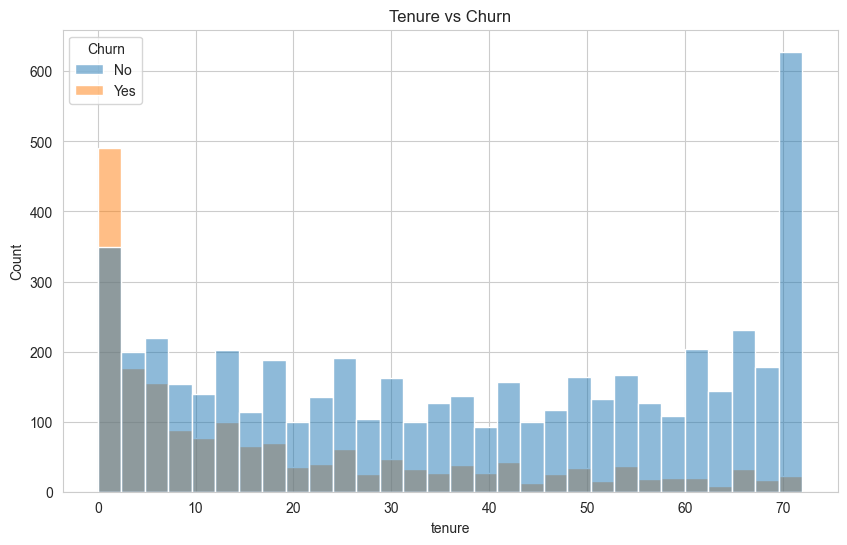

In [25]:
#GRAPH 3: Tenure vs Churn
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.title("Tenure vs Churn")
plt.show()

In [26]:
#New customers (low tenure) churn more

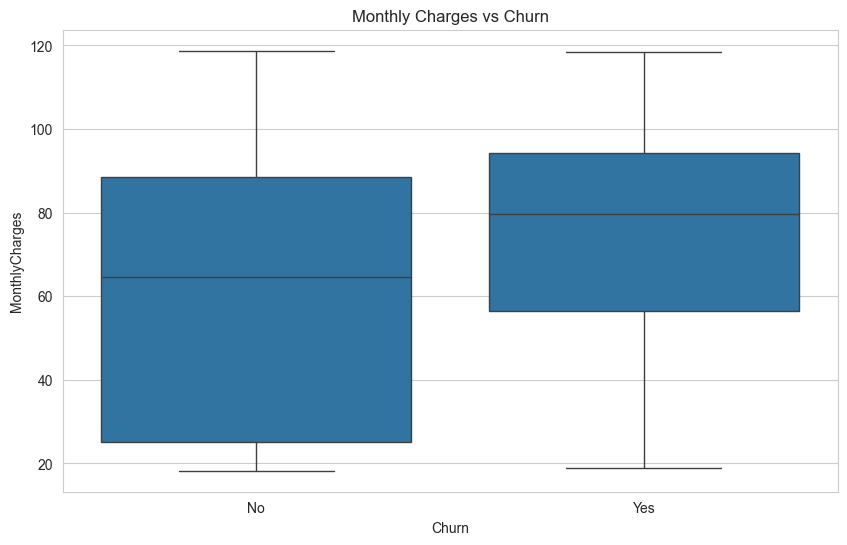

In [27]:
#GRAPH 4: Monthly Charges vs Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title("Monthly Charges vs Churn")
plt.show()

In [28]:
#High-paying customers churn more

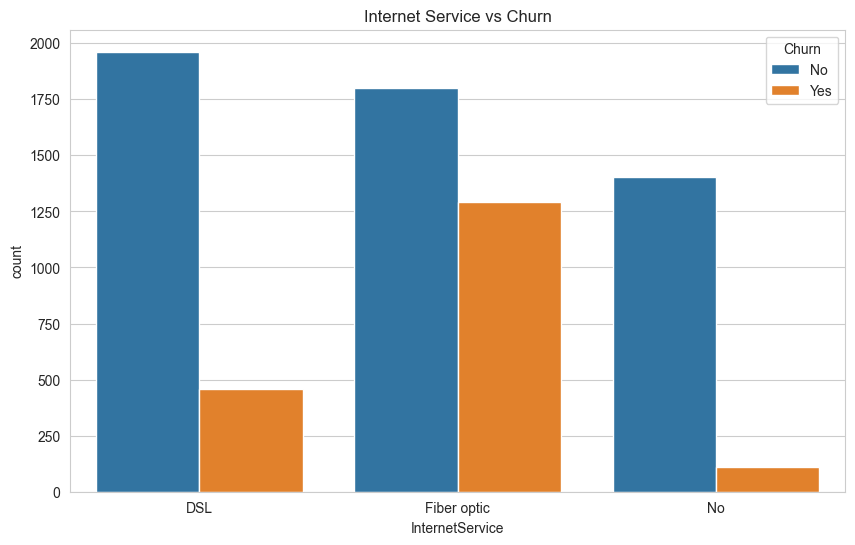

In [29]:
#GRAPH 5: Internet Service vs Churn
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title("Internet Service vs Churn")
plt.show()

In [30]:
#Fiber optic users churn more

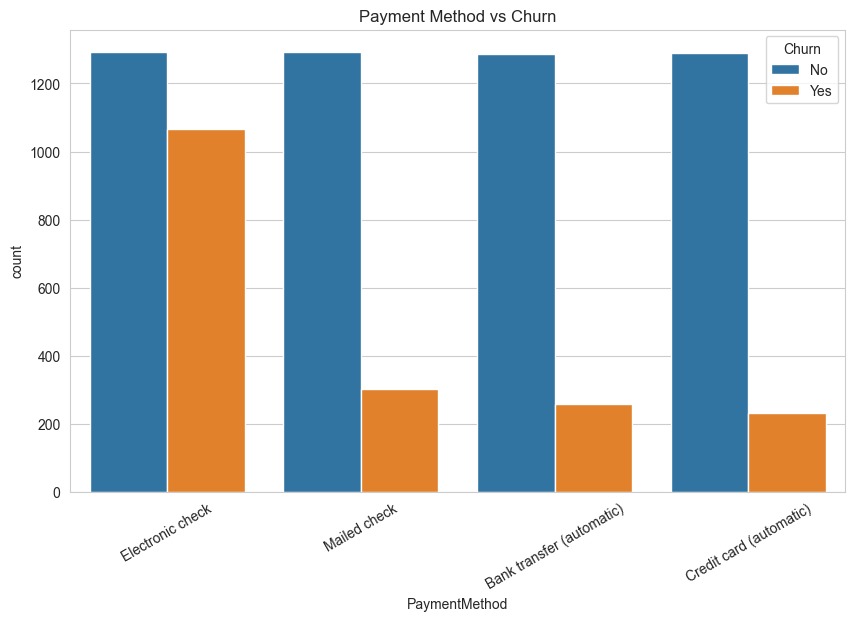

In [31]:
#GRAPH 6: Payment Method vs Churn
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=30)
plt.title("Payment Method vs Churn")
plt.show()

In [32]:
#Electronic check users churn the most

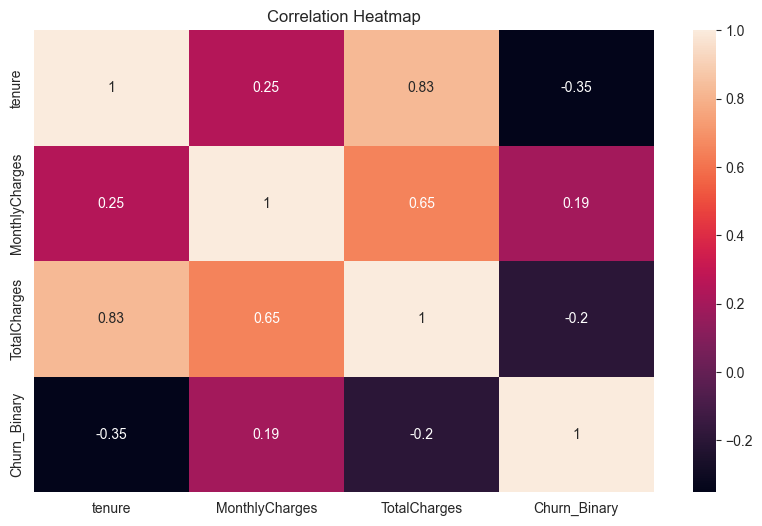

In [33]:
#GRAPH 7: Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [34]:
#Tenure has strong negative relation with churn

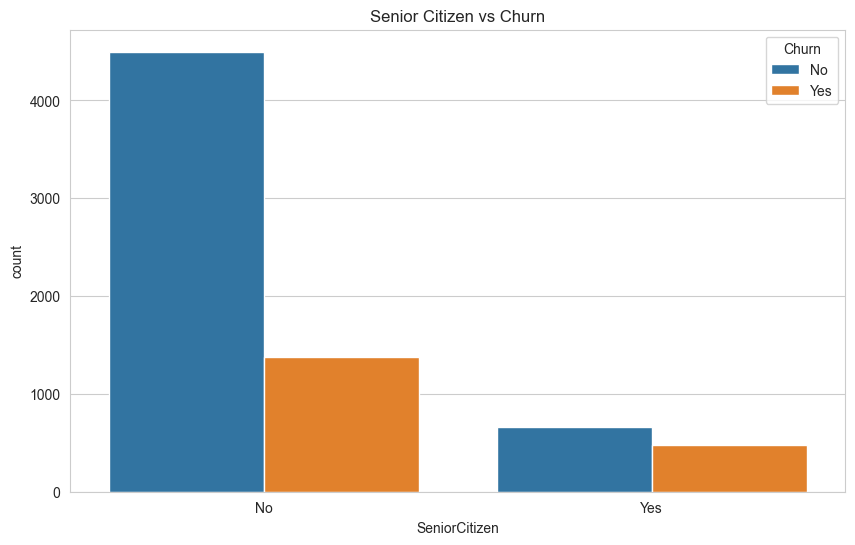

In [35]:
#GRAPH 8: Senior Citizen vs Churn
sns.countplot(data=df, x='SeniorCitizen', hue='Churn')
plt.title("Senior Citizen vs Churn")
plt.show()

In [36]:
#Senior citizens churn more

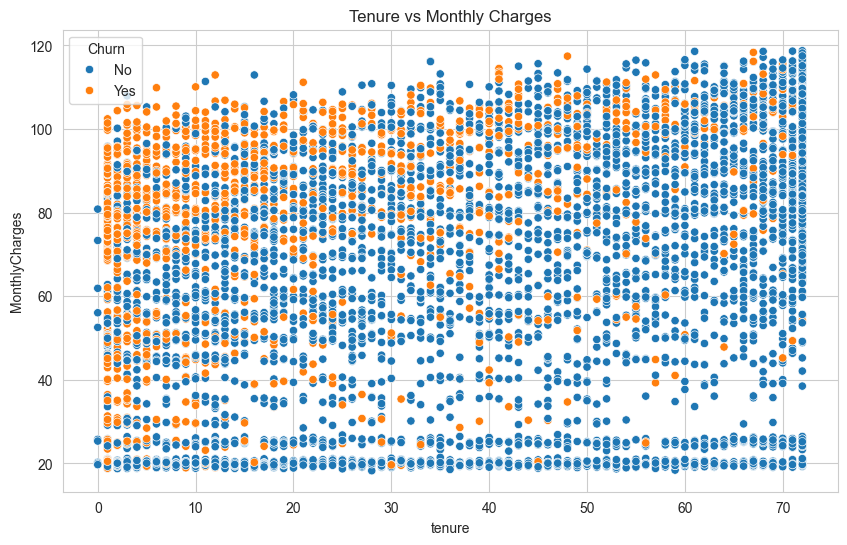

In [37]:
#GRAPH 9: Scatter Plot
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn')
plt.title("Tenure vs Monthly Charges")
plt.show()

In [38]:
#High charges + low tenure = high churn

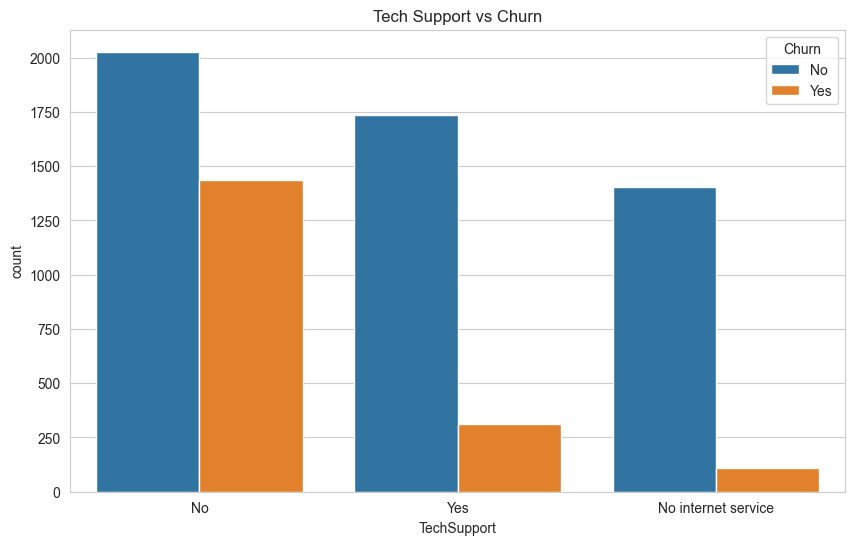

In [39]:
#GRAPH 10: TechSupport vs Churn
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title("Tech Support vs Churn")
plt.show()

In [40]:
#Customers without tech support churn more

In [41]:
plt.savefig("graph1.png")
#EDA ENDS

<Figure size 1000x600 with 0 Axes>

In [42]:
#MACHINE LEARNING (Churn Prediction)
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,tenure,MonthlyCharges,TotalCharges,Churn_Binary,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,1,29.85,29.85,0,False,False,True,False,False,True,...,False,False,False,False,False,True,False,True,False,False
1,34,56.95,1889.50,0,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
2,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,True,False,False,True,True
3,45,42.30,1840.75,0,True,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False
4,2,70.70,151.65,1,False,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,True


In [50]:
X = df_encoded.drop(['Churn_Yes', 'Churn_Binary'], axis=1, errors='ignore')
y = df_encoded['Churn_Yes']

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [52]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
y_pred = model.predict(X_test)

In [54]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7935943060498221
              precision    recall  f1-score   support

       False       0.84      0.89      0.87      1053
        True       0.61      0.49      0.54       352

    accuracy                           0.79      1405
   macro avg       0.72      0.69      0.71      1405
weighted avg       0.78      0.79      0.79      1405



In [55]:
RandomForestClassifier(class_weight='balanced')

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
